# CosMx Pancreas - Attention matrix evaluation

Evaluate attention matrix from trained regression model.

In [122]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd

## plotting imports
import matplotlib.pyplot as plt
import seaborn as sns

## InterScale imports
import InterScale as interscale
from InterScale.config import load_config
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule
#from InterScale.eval.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
from InterScale.tl import prepare_a2d_dataset
from InterScale.evaluation import scale_cls_by_sample

from pathlib import Path
import torch

## Set up paths

Check which cluster by testing for distinctive directories then set:

- `BASE_DIR_REPO`: path to github repo (InterScale code)
- `BASE_DIR_PROJECT`: path to project folder, where results, models, etc are stored

In [65]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'

LRZ cluster


In [3]:
# path on ICB or LRZ cluster to InterScale_reproducibility folder
CFG_CLASS = os.path.join(BASE_DIR_REPO, "GT-long-range-niches/src/config_files/Cosmx_pancreas/regr_InterScale.yaml")
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, "results/melton25/")
FIGURE_DIR = os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/melton25")

In [4]:
path = os.path.join("/home", "user", "documents", "/etc", "config.txt")
path

'/etc/config.txt'

## Figure settings

In [144]:
import yaml
import matplotlib.pyplot as plt

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"]["Melton_Jimenez"]

In [148]:
CELL_TYPE_KEY = 'cell_type_coarse'

## Load config and model

In [6]:
cfg = load_config(CFG_CLASS)

In [7]:
assert BASE_DIR_PROJECT in cfg.model.save 
assert BASE_DIR_PROJECT in cfg.dataset.h5ad_data

In [8]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

In [151]:
# assign cell type colors
color_list = [CELL_TYPE_COLORS[ct] for ct in adata.obs[CELL_TYPE_KEY].cat.categories]
adata.uns[f'{CELL_TYPE_KEY}_colors'] = color_list

In [9]:
model_name = os.path.join('melton25_regr_node_44_GCN_self-attn-transformer_')

In [10]:
'melton25_regr_node_44_GCN_self-attn-transformer_' == 'melton25_regr_node_44_GCN_self-attn-transformer_'

True

In [11]:
#interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
#local_model = interscale.model.LocalModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = False, wandb_save = True)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
combined_model = interscale.model.CombinedModel.load(RESULTS_DIR, adata, cfg, model_name = model_name, local_component = True, global_component = True, wandb_save = True)

Loading model from /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/melton25/melton25_regr_node_44_GCN_self-attn-transformer_model.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/model/base/_base_model.py:591: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be f

## Inference: get model output 

In [112]:
slide_ids = list(config["slide_examples"]["Melton_Jimenez"].values())

['1_12', '1_10']

In [113]:
sub_adata = adata[adata.obs['slide_fov'].isin(slide_ids)]

In [114]:
result = combined_model.get_model_output(sub_adata, prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    
Load GEX from .X
call new


/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [115]:
result

AnnData object with n_obs × n_vars = 9631 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_key', 'combined_cls_horizontal', 'combined_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 

In [32]:
def normalized_attention(attention_matrix, clamp = 0.05):
    np.fill_diagonal(attention_matrix.values, 0)
    
    # Clamp and scale attention matrix
    scores = torch.tensor(attention_matrix.values)
    if clamp:
        q05, q95 = torch.quantile(scores, clamp), torch.quantile(scores, 1-clamp)
        scores = np.clip(scores, a_min=q05, a_max=q95)
    scores = MinMaxScaler(feature_range=(0, 1)).fit_transform(scores)
    return scores

def normalized_class_attention(adata, attn_matrix_key, class_key, clamp: int = 0.05):
    """
    Given an attention matrix of size NxN with K classes it returns a normalized attention matrix KxK.
    Each element in the normalized attention matrix can be interpreted as class k_i paying attention to class k_j, where i and j are elements of the K classes.

    Parameters
    ----------
        attention_matrix: AnnData
        attn_matrix_key: str
            Key in .obsm pointing to saved attention matrix during inference
        class_key: str
            Key pointing to class in .obs which is used to normalize over
    Returns
    -------
        attn_norm: 
            KxK, where 
    """
    scores = normalized_attention(attention_matrix, clamp)
    attention_matrix = pd.DataFrame(scores, index = attention_matrix.index, columns = attention_matrix.columns)
    
    # Create an empty KxK DataFrame to store the summed and normalized attention values
    class_names = np.unique(attention_matrix.columns)
    K = len(class_names)
    attn_norm = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)

    # Iterate over each unique cell type combination
    for i, class_i in enumerate(class_names):
        for j, class_j in enumerate(class_names):
            # Find the indices in the original CxC DataFrame that correspond to the given cell types
            indices_i = (attention_matrix.index == class_i)
            indices_j = (attention_matrix.columns == class_j)
            norm_value = attention_matrix.loc[indices_i, indices_j].sum() / len(np.argwhere(indices_i==True))
            summed_value = norm_value.sum() / len(np.argwhere(indices_j==True))
            attn_norm.at[class_i, class_j] = summed_value

    return attn_norm

In [35]:
def normalized_class_attention(
    adata, 
    attn_matrix_key, 
    class_key, 
    clamp: float = 0.05,
    key_added: str = None,
    copy: bool = False
):
    """
    Given an attention matrix of size NxN with K classes it returns a normalized attention matrix KxK.
    Each element in the normalized attention matrix can be interpreted as class k_i paying attention 
    to class k_j, where i and j are elements of the K classes.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object containing attention matrix and cell type annotations
    attn_matrix_key : str
        Key in .obsm pointing to saved attention matrix during inference
    class_key : str
        Key pointing to class in .obs which is used to normalize over
    clamp : float, optional
        Quantile value for clamping (default: 0.05)
    key_added : str, optional
        If provided, save normalized attention matrix to adata.uns[key_added].
        If None, return the matrix instead.
    copy : bool, optional
        If True, return a copy of adata with the result added. Only relevant if key_added is not None.
        (default: False)
    
    Returns
    -------
    If key_added is None:
        attn_norm : pd.DataFrame
            KxK DataFrame where entry (i,j) represents mean normalized attention from class i to class j
    If key_added is not None and copy is False:
        None (modifies adata in place)
    If key_added is not None and copy is True:
        adata : AnnData
            Copy of adata with normalized attention added to .uns
    """
    adata = adata.copy() if copy else adata
    
    # Extract attention matrix from adata
    attention_matrix = adata.obsm[attn_matrix_key]
    
    # Convert to DataFrame with cell indices
    attention_df = pd.DataFrame(
        attention_matrix, 
        index=adata.obs_names, 
        #columns=adata.obs_names
    )
    
    # Normalize the attention matrix (clamp outliers and scale to [0,1])
    #scores = normalized_attention(attention_df, clamp)
    attention_df = pd.DataFrame(attention_df, index=attention_df.index, columns=attention_df.columns)
    
    # Get cell type labels for each cell
    cell_types = adata.obs[class_key]
    
    # Get unique cell types
    class_names = cell_types.unique()
    K = len(class_names)
    
    # Create empty KxK DataFrame to store normalized attention values
    attn_norm = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)
    
    # Compute mean attention for each cell type pair
    for class_i in class_names:
        for class_j in class_names:
            # Find cells belonging to each type
            cells_i = cell_types == class_i
            cells_j = cell_types == class_j
            
            # Extract submatrix: attention from cells of type i to cells of type j
            submatrix = attention_df.loc[cells_i, cells_j]
            
            # Compute mean attention (averaged over all source-target cell pairs)
            attn_norm.at[class_i, class_j] = submatrix.values.mean()
    
    # Save to adata or return
    if key_added is not None:
        adata.uns[key_added] = attn_norm
        return adata if copy else None
    else:
        return attn_norm

In [36]:
result.obsm['combined_attn_matrix']

array([[1.0, 1.0239158854119523e-08, 2.400628485977024e-16, ..., nan,
        nan, nan],
       [1.2323987164108985e-08, 1.0, 5.028809196860363e-16, ..., nan,
        nan, nan],
       [3.200409537384985e-08, 2.4025677447525595e-08, 1.0, ..., nan,
        nan, nan],
       ...,
       [8.992866867840732e-11, 2.5671480496924914e-09,
        3.637109924082551e-15, ..., nan, nan, nan],
       [1.9216173097191813e-09, 2.3063024823244405e-09,
        1.2170582314711574e-15, ..., nan, nan, nan],
       [4.880400528151085e-09, 1.7082201209106529e-09,
        7.640491794802529e-09, ..., nan, nan, nan]], dtype=object)

In [38]:
attn_norm = normalized_class_attention(result, 'combined_attn_matrix', 'cell_type_coarse', copy = True)

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

def normalized_attention(attention_matrix, clamp=0.05):
    # Ensure it's a numeric numpy array
    if isinstance(attention_matrix, pd.DataFrame):
        scores = attention_matrix.values.astype(np.float32)
    else:
        scores = np.array(attention_matrix, dtype=np.float32)
    
    # Set diagonal to 0
    np.fill_diagonal(scores, 0)
    
    # Clamp and scale attention matrix
    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    if clamp:
        q05 = torch.quantile(scores_tensor, clamp)
        q95 = torch.quantile(scores_tensor, 1-clamp)
        scores = np.clip(scores, a_min=q05.item(), a_max=q95.item())
    
    scores = MinMaxScaler(feature_range=(0, 1)).fit_transform(scores)
    return scores

# Get unique cell types
class_key = 'cell_type_coarse'
class_names = result.obs[class_key].unique()
K = len(class_names)

# Store normalized attention matrices for each sliding window
window_attn_matrices = []

for sliding_wind in np.unique(result.obs['sliding_window_square']):
    sub_result = result[result.obs['sliding_window_square'] == sliding_wind]
    n_cells = sub_result.shape[0]
    print(f"Window {sliding_wind}: Nr of cells: {n_cells}")
    
    # Extract the NxN attention matrix for this window
    attn_matrix = sub_result.obsm['combined_attn_matrix'][:, :n_cells]
    
    # Convert to DataFrame (ensure numeric)
    attn_df = pd.DataFrame(
        attn_matrix.astype(np.float32),
        index=sub_result.obs_names,
        columns=sub_result.obs_names
    )
    
    # Apply normalization (clamp outliers and scale to [0,1])
    attn_normalized = normalized_attention(attn_df, clamp=0.05)
    
    # Get cell types for cells in this window
    cell_types = sub_result.obs[class_key].values
    
    # Create KxK normalized attention matrix for this window
    attn_norm_window = pd.DataFrame(
        np.zeros((K, K)), 
        index=class_names, 
        columns=class_names
    )
    
    # Compute mean attention for each cell type pair
    for class_i in class_names:
        for class_j in class_names:
            # Find cells of each type
            cells_i = cell_types == class_i
            cells_j = cell_types == class_j
            
            # Skip if either cell type is not present
            if not cells_i.any() or not cells_j.any():
                continue
            
            # Get indices
            i_indices = np.where(cells_i)[0]
            j_indices = np.where(cells_j)[0]
            
            # Extract submatrix: attention from cells of type i to cells of type j
            submatrix = attn_normalized[np.ix_(i_indices, j_indices)]
            
            # Compute mean attention
            attn_norm_window.at[class_i, class_j] = submatrix.mean()
    
    window_attn_matrices.append(attn_norm_window)
    print(f"  Normalized to {K}x{K} class attention matrix")

# Average across all windows
attn_norm_avg = pd.DataFrame(
    np.zeros((K, K)), 
    index=class_names, 
    columns=class_names
)

for class_i in class_names:
    for class_j in class_names:
        # Collect values from all windows (excluding zero entries)
        values = [m.at[class_i, class_j] for m in window_attn_matrices 
                 if m.at[class_i, class_j] > 0]
        
        if len(values) > 0:
            attn_norm_avg.at[class_i, class_j] = np.mean(values)
        else:
            attn_norm_avg.at[class_i, class_j] = 0

# Scale final matrix to [0, 1]
min_val = attn_norm_avg.values.min()
max_val = attn_norm_avg.values.max()

if max_val > min_val:  # Avoid division by zero
    attn_norm_avg = (attn_norm_avg - min_val) / (max_val - min_val)
else:
    attn_norm_avg = attn_norm_avg * 0  # All zeros if no variation

print("\nFinal averaged normalized attention matrix (scaled to [0,1]):")
print(attn_norm_avg)

print("\nFinal averaged normalized attention matrix:")
print(attn_norm_avg)

In [43]:
attn_norm = pd.DataFrame(result.obsm['combined_attn_matrix'])

In [46]:
 # Identify columns (and rows) with all NaN values
nan_cols = attn_norm.columns[attn_norm.isna().all(axis=0)].tolist()
nan_rows = attn_norm.index[attn_norm.isna().all(axis=1)].tolist()

assert attn_norm.shape[1] - len(nan_cols) == attn_norm.shape[0]

if nan_cols or nan_rows:
    print(f"Warning: Found cell types with all NaN values:")
    if nan_cols:
        print(f"  Columns (target): {len(nan_cols)}")
    if nan_rows:
        print(f"  Rows (source): {nan_rows}")

AssertionError: 

In [50]:
attn_norm.shape[0] - len(nan_cols)

3223

In [116]:
result.obs['condition']

1       T1D
2       T1D
3       T1D
4       T1D
5       T1D
       ... 
9627     ND
9628     ND
9629     ND
9630     ND
9631     ND
Name: condition, Length: 9631, dtype: category
Categories (2, object): ['ND', 'T1D']

## Can we interpret the CLS token on regression trained model?

First, scale the CLS token per sliding window so that they are comparable despite their different number of cells. 

In [120]:
result_t1d = result[result.obs['condition'] == 'T1D']
scale_cls_by_sample(result_t1d, "slide_fov")
result_nd = result[result.obs['condition'] == 'ND']
scale_cls_by_sample(result_nd, "slide_fov")

/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/evaluation/graph_classification.py:79: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[scaled_col_name] = scaled_data[scaled_col_name]
/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/evaluation/graph_classification.py:79: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[scaled_col_name] = scaled_data[scaled_col_name]


/tmp/ipykernel_907546/281037178.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_t1d = result_t1d.obs.groupby('cell_type_coarse').agg(
/tmp/ipykernel_907546/281037178.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_nd = result_nd.obs.groupby('cell_type_coarse').agg(


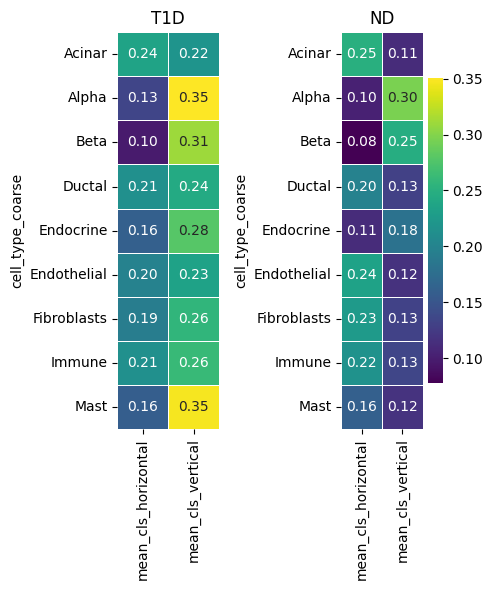

In [137]:
data_t1d = result_t1d.obs.groupby('cell_type_coarse').agg(
    mean_cls_horizontal=('combined_cls_horizontal_scaled', 'mean'),
    mean_cls_vertical=('combined_cls_vertical_scaled', 'mean')
)

data_nd = result_nd.obs.groupby('cell_type_coarse').agg(
    mean_cls_horizontal=('combined_cls_horizontal_scaled', 'mean'),
    mean_cls_vertical=('combined_cls_vertical_scaled', 'mean')
)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 6))

# Get min/max for shared color scale
vmin = min(data_t1d.values.min(), data_nd.values.min())
vmax = max(data_t1d.values.max(), data_nd.values.max())

# Plot with shared color scale
sns.heatmap(data_t1d, annot=True, linewidth=.5, fmt='.2f', 
            ax=axes[0], vmin=vmin, vmax=vmax, cbar=False, cmap = PALETTE)
axes[0].set_title('T1D')

sns.heatmap(data_nd, annot=True, linewidth=.5, fmt='.2f', 
            ax=axes[1], vmin=vmin, vmax=vmax, cmap = PALETTE)
axes[1].set_title('ND')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


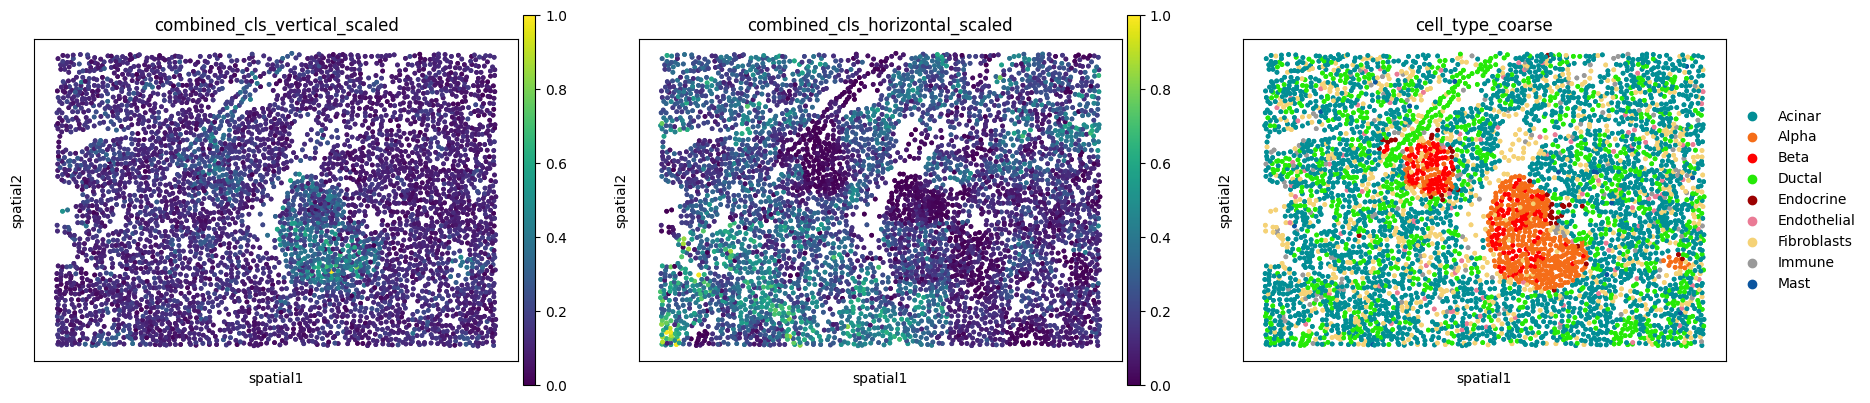

In [153]:
sq.pl.spatial_scatter(result_nd, 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', 'cell_type_coarse'],
                    cmap = PALETTE,
                    shape= None,
                      ncols = 3,
)

In [152]:
# assign cell type colors
color_list = [CELL_TYPE_COLORS[ct] for ct in result_nd.obs[CELL_TYPE_KEY].cat.categories]
result_nd.uns[f'{CELL_TYPE_KEY}_colors'] = color_list

/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


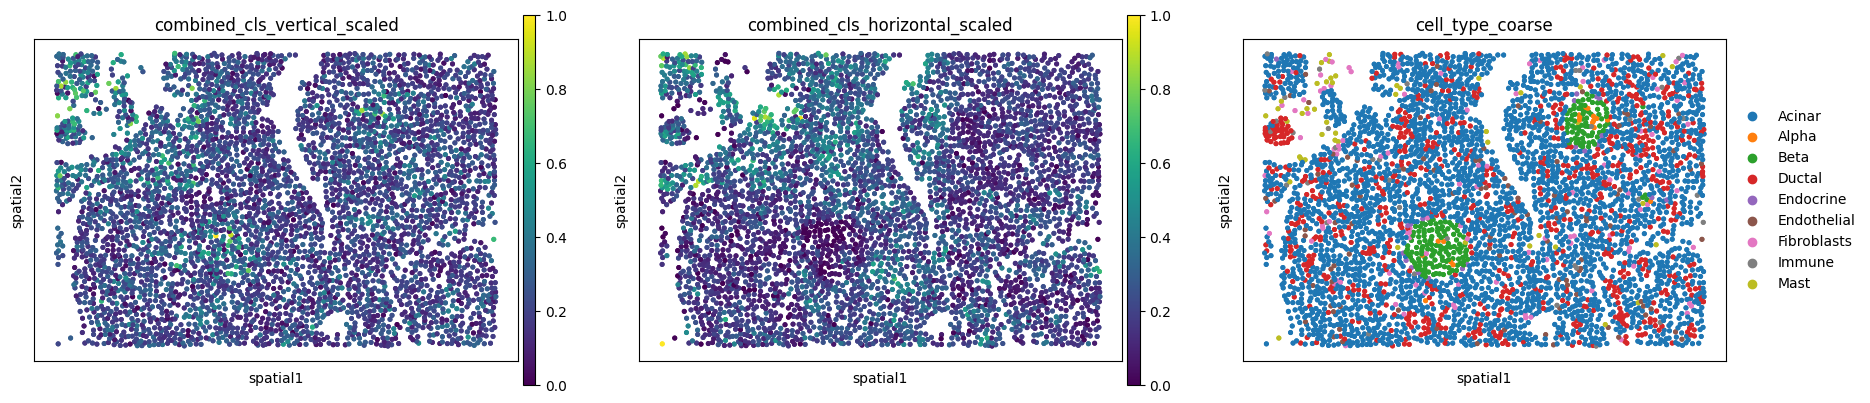

In [139]:
sq.pl.spatial_scatter(result_t1d, 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', 'cell_type_coarse'],
                   cmap = PALETTE,
                    shape= None,
                      ncols = 3,
)